### Data Gathering

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [4]:
df = pd.read_csv('International_Education_Costs.csv')
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


In [5]:
df.describe()

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    object 
 1   City               907 non-null    object 
 2   University         907 non-null    object 
 3   Program            907 non-null    object 
 4   Level              907 non-null    object 
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 85.2+ KB


In [7]:
df.shape

(907, 12)

In [8]:
df.size

10884

### Occurance 

In [9]:
df['Country'].value_counts()

Country
UK                93
Australia         86
USA               78
Canada            76
Germany           33
                  ..
Czech Republic     1
Hong Kong          1
Israel             1
Nigeria            1
Vietnam            1
Name: count, Length: 71, dtype: int64

In [11]:
df['Country'].unique()

array(['USA', 'UK', 'Canada', 'Australia', 'Germany', 'Japan',
       'Netherlands', 'Singapore', 'France', 'Switzerland', 'Sweden',
       'Denmark', 'China', 'South Korea', 'Ireland', 'New Zealand',
       'Austria', 'Belgium', 'Hong Kong', 'Portugal', 'Israel', 'Taiwan',
       'Czech Republic', 'India', 'Poland', 'Malaysia', 'Spain', 'Italy',
       'Finland', 'Norway', 'Brazil', 'Turkey', 'Russia', 'Mexico',
       'Greece', 'Thailand', 'UAE', 'South Africa', 'Egypt', 'Argentina',
       'Indonesia', 'Saudi Arabia', 'Nigeria', 'Vietnam', 'Hungary',
       'Iceland', 'Colombia', 'Romania', 'Luxembourg', 'Tunisia',
       'Cyprus', 'Croatia', 'Dominican Republic', 'Morocco', 'Peru',
       'Ecuador', 'Lebanon', 'Bahrain', 'Uruguay', 'Bulgaria', 'Ghana',
       'Algeria', 'Panama', 'Bangladesh', 'Kuwait', 'Ukraine', 'Slovenia',
       'Serbia', 'Iran', 'Uzbekistan', 'El Salvador'], dtype=object)

In [14]:
df[df['Country'] == 'India']

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
44,India,Bangalore,Indian Institute of Science,Computer Science,Master,2.0,2500,45.6,500,200,300,83.20
648,India,Bangalore,Indian Institute of Science,Data Science,PhD,4.0,2000,45.2,300,180,300,82.75
654,India,Mumbai,IIT Bombay,Computer Engineering,Master,2.0,1800,47.5,350,180,300,82.75
659,India,Delhi,IIT Delhi,Artificial Intelligence,PhD,4.0,1900,44.8,320,180,300,82.75
665,India,Chennai,IIT Madras,Software Engineering,Master,2.0,1700,42.4,280,180,300,82.75
671,India,Hyderabad,IIT Hyderabad,Data Analytics,PhD,4.0,1800,41.2,260,180,300,82.75
677,India,Pune,IIT Pune,Computer Science,Master,2.0,1600,40.5,250,180,300,82.75
683,India,Kanpur,IIT Kanpur,Artificial Intelligence,PhD,4.0,1900,39.8,240,180,300,82.75


In [15]:
df["City"].value_counts()

City
Singapore      18
Sydney         11
Melbourne      11
London         10
Canberra        8
               ..
Penang          1
Santa Tecla     1
Andijan         1
Tabriz          1
Subotica        1
Name: count, Length: 556, dtype: int64

In [16]:
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='object')

In [17]:
df['Program'].value_counts()

Program
Computer Science           312
Data Science                82
Computer Engineering        71
Software Engineering        57
Artificial Intelligence     53
                          ... 
Electronics                  1
Electronic Engineering       1
Digital Design               1
Digital Business             1
Data Systems                 1
Name: count, Length: 92, dtype: int64

In [18]:
df['University'].value_counts()

University
University of Washington           6
Stanford University                5
Australian National University     5
University of Tasmania             5
University of Western Australia    5
                                  ..
USM                                1
Universidad Politecnica            1
Imperial College                   1
ITCA-FEPADE                        1
Andijan State University           1
Name: count, Length: 622, dtype: int64

In [19]:
 df['Level'].value_counts()

Level
Master      451
Bachelor    297
PhD         159
Name: count, dtype: int64

In [20]:
 df['Duration_Years'].min()

np.float64(1.0)

In [21]:
 df['Duration_Years'].max()

np.float64(5.0)

In [22]:
 df['Duration_Years'].mean()

np.float64(2.8368246968026463)

In [23]:
df.isnull().sum()

Country              0
City                 0
University           0
Program              0
Level                0
Duration_Years       0
Tuition_USD          0
Living_Cost_Index    0
Rent_USD             0
Visa_Fee_USD         0
Insurance_USD        0
Exchange_Rate        0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.dtypes

Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

### SIZE REDUCTION

In [31]:
df['Duration_Years'] = df['Duration_Years'].astype('float32')
df['Tuition_USD'] = df['Tuition_USD'].astype('int32')
df['Rent_USD'] = df['Rent_USD'].astype('int32')
df['Visa_Fee_USD'] = df['Visa_Fee_USD'].astype('int32')
df['Insurance_USD'] = df['Insurance_USD'].astype('float32')

In [32]:
df.dtypes 

Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float32
Tuition_USD            int32
Living_Cost_Index    float64
Rent_USD               int32
Visa_Fee_USD           int32
Insurance_USD        float32
Exchange_Rate        float64
dtype: object

### UNI-VARIENT ANALYSIS

In [33]:
df['Country'].value_counts().head(10)

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [35]:
country = df[df['Country'].isin(['UK','USA','Australia','Canada','Germany','France','South Korea','Netherlands','Switzerland','Singapore'])]

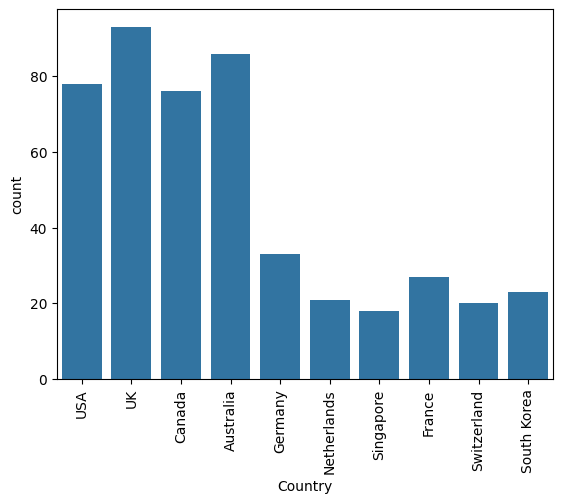

In [37]:
sns.countplot(data = country, x = 'Country')
plt.xticks(rotation = 'vertical')
plt.show()

In [38]:
df['City'].value_counts().head()

City
Singapore    18
Sydney       11
Melbourne    11
London       10
Canberra      8
Name: count, dtype: int64

In [39]:
city = df[df['City'].isin(['Singapore','Sydney','Melbourne','London','Canberra'])]

<Axes: xlabel='City', ylabel='count'>

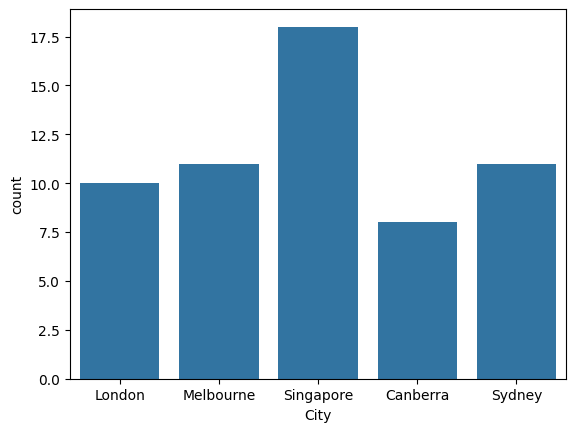

In [40]:
sns.countplot(data = city, x ='City')

<Axes: xlabel='Level', ylabel='count'>

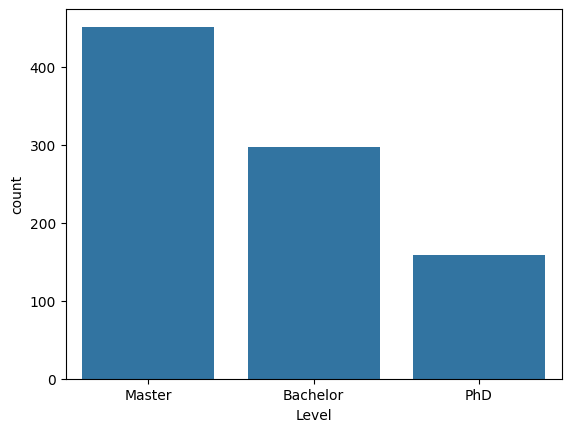

In [41]:
sns.countplot(data = df , x = 'Level')

In [52]:
d1 = df[df['Level'] == 'Master'].head(150)
d2 = df[df['Level'] == 'Bachelor'].head(150)
d3 = df[df['Level'] == 'PhD'].head(150)
d4 = pd.concat([d1,d2,d3])

In [53]:
d4.shape

(450, 12)

<Axes: xlabel='Duration_Years', ylabel='Count'>

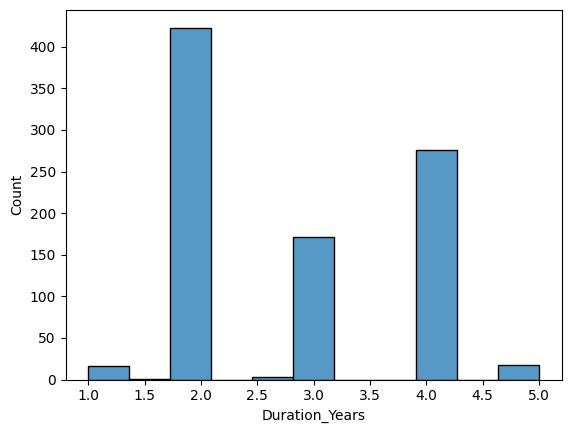

In [54]:
sns.histplot(data = df, x = 'Duration_Years')

<Axes: xlabel='Duration_Years', ylabel='Count'>

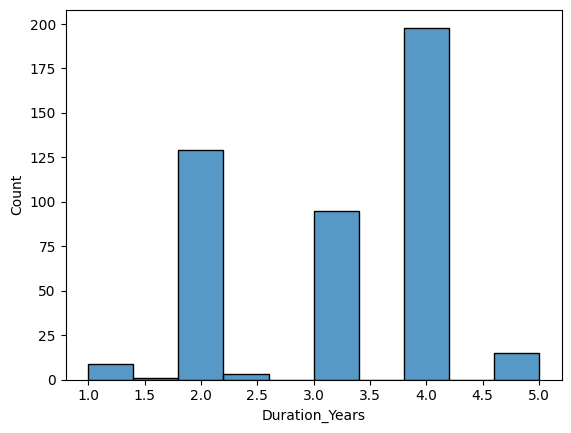

In [56]:
sns.histplot(data = d4, x = 'Duration_Years')

<Axes: xlabel='Tuition_USD', ylabel='Count'>

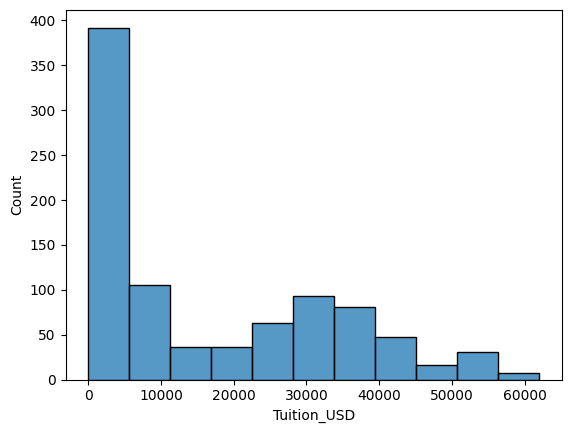

In [57]:
sns.histplot(data = df, x = 'Tuition_USD')

<Axes: xlabel='Rent_USD', ylabel='Count'>

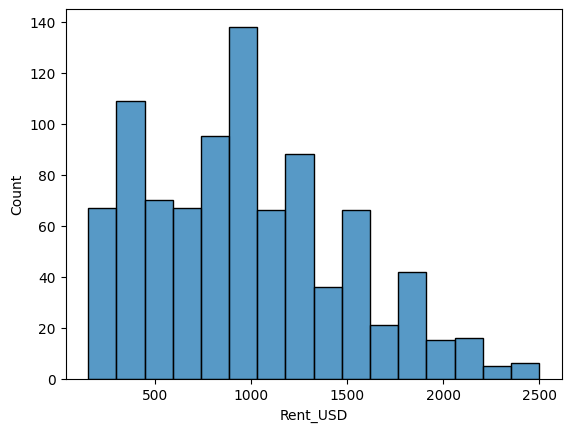

In [58]:
sns.histplot(data = df, x = "Rent_USD")

<Axes: xlabel='Rent_USD', ylabel='Density'>

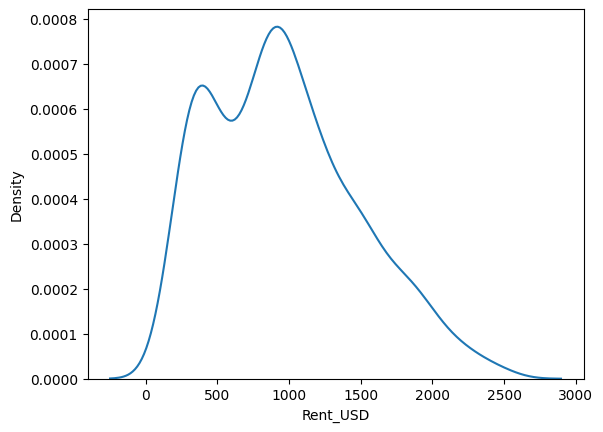

In [59]:
sns.kdeplot(data = df , x ='Rent_USD')

<Axes: xlabel='Rent_USD'>

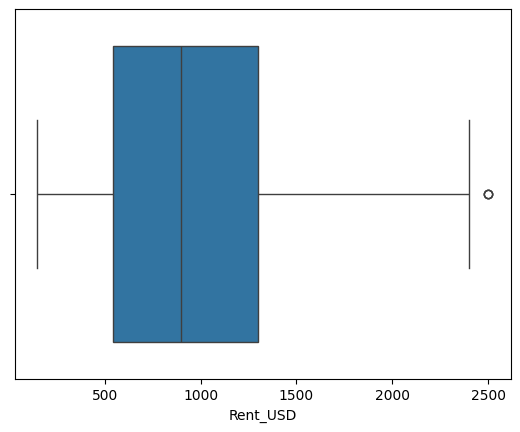

In [60]:
sns.boxplot(data = df, x = 'Rent_USD')

### BI-VARIENT ANALYSIS

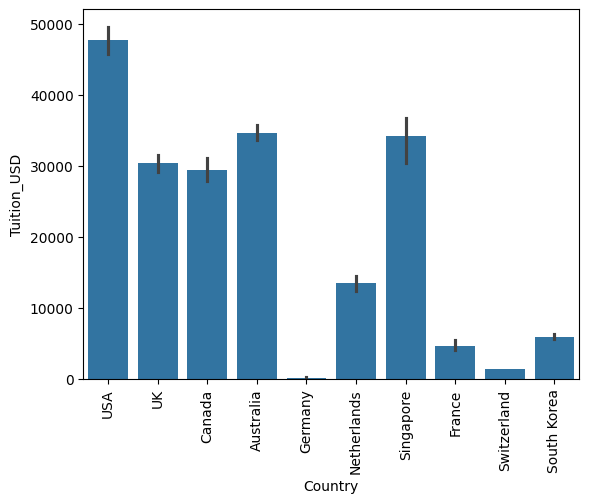

In [63]:
sns.barplot(data = country, x = 'Country' , y = 'Tuition_USD')
plt.xticks(rotation = 'vertical')
plt.show()

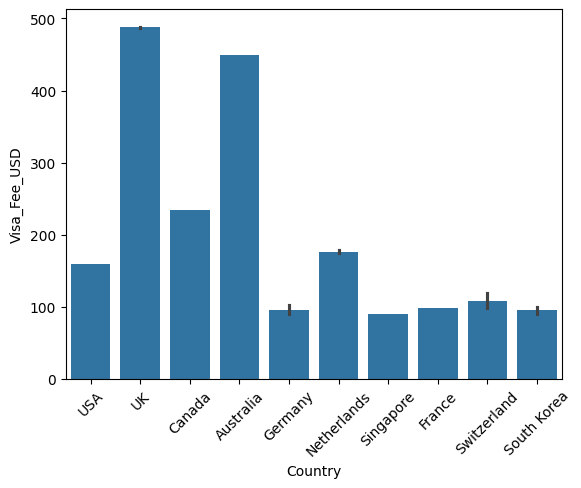

In [65]:
sns.barplot(data = country, x = 'Country', y = 'Visa_Fee_USD')
plt.xticks(rotation = 45)
plt.show()

In [66]:
df['University'].value_counts().head(10)

University
University of Washington           6
Stanford University                5
Australian National University     5
University of Tasmania             5
University of Western Australia    5
University of Adelaide             5
Griffith University                5
University of Sydney               5
University of Melbourne            5
University of Wollongong           5
Name: count, dtype: int64

In [68]:
university = df[df['University'].isin(['University of Washington','Stanford University','Australian National University','University of Tasmania','University of Western Australia','University of Adelaide','Griffith University','University of Sydney','University of Melbourne','University of Wollongong'])]

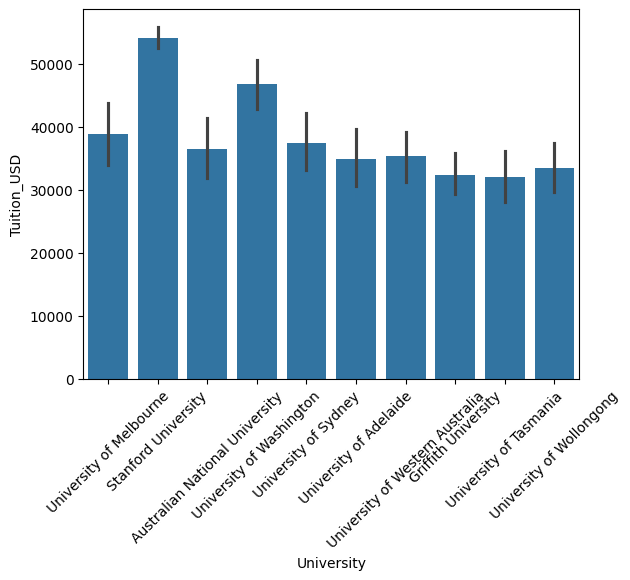

In [72]:
sns.barplot(data = university, x= 'University', y = 'Tuition_USD')
plt.xticks(rotation =45)
plt.show()

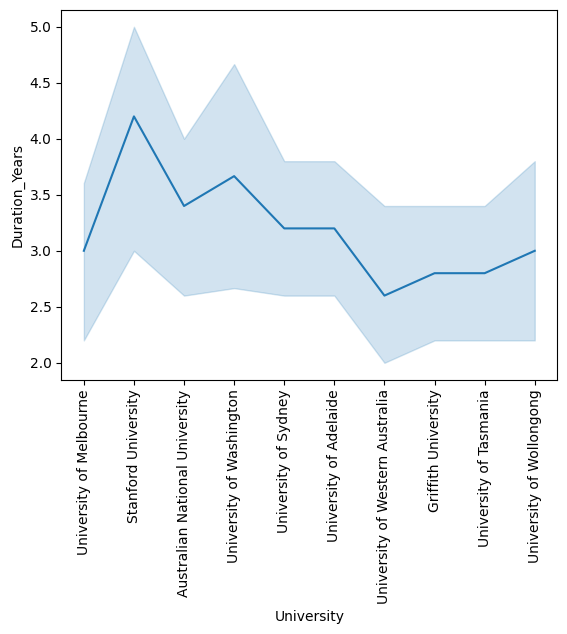

In [75]:
sns.lineplot(data = university, x= 'University', y = 'Duration_Years')
plt.xticks(rotation = 90)
plt.show()

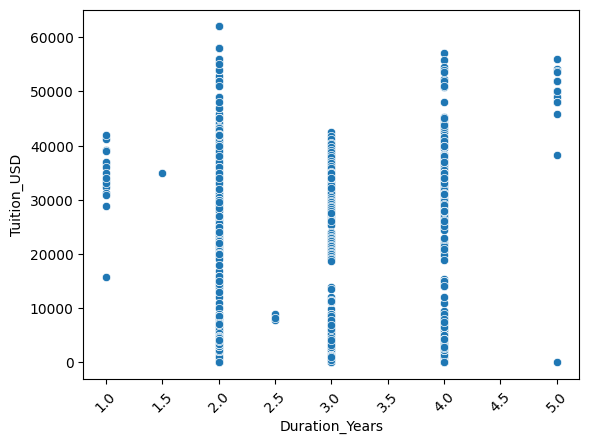

In [76]:
sns.scatterplot(data= df , x='Duration_Years', y = 'Tuition_USD')
plt.xticks(rotation =45)
plt.show()

### TOP 10 COUNTRIES ----> TOP 10 UNIVERSITY -----> TUITION FEES

In [82]:
country['Country'].value_counts()

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [83]:
country['University'].value_counts().head(10)

University
University of Washington           6
Stanford University                5
Griffith University                5
University of Western Australia    5
University of Adelaide             5
University of Tasmania             5
University of Newcastle            5
Australian National University     5
University of Wollongong           5
University of Sydney               5
Name: count, dtype: int64

In [84]:
university = country[country['University'].isin(['University of Washington','Stanford University','Australian National University','University of Tasmania','University of Western Australia','University of Adelaide','Griffith University','University of Sydney','University of Newcastle','University of Wollongong'])]

### Feature Engineering ----> Means building or making new columns/features.

In [85]:
df['Total_cost'] = df['Tuition_USD'] + df['Rent_USD']

In [86]:
df

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500.0,1.00,57600
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800.0,0.79,43000
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900.0,1.35,40100
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650.0,1.52,43400
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550.0,0.92,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.2,1000,99,850.0,0.92,5000
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800,50.5,400,120,400.0,4.65,7200
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200,64.2,600,200,800.0,3.75,4800
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.8,2000,160,1500.0,1.00,52000


### ENCODERS -------- 1. LABEL ENCODER --------- 2. ORDINAL ENCODER ------------- 3. ONE HOT ENCODER

In [87]:
from sklearn.preprocessing import LabelEncoder

In [88]:
le = LabelEncoder()

In [91]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_cost
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500.0,1.00,57600
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800.0,0.79,43000
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900.0,1.35,40100
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650.0,1.52,43400
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550.0,0.92,1600


In [92]:
df['Country'] = le.fit_transform(df['Country'])
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_cost
0,66,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500.0,1.00,57600
1,65,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800.0,0.79,43000
2,9,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900.0,1.35,40100
3,2,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650.0,1.52,43400
4,22,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550.0,0.92,1600


In [93]:
df['City'] = le.fit_transform(df['City'])
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_cost
0,66,84,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500.0,1.00,57600
1,65,283,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800.0,0.79,43000
2,9,503,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900.0,1.35,40100
3,2,313,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650.0,1.52,43400
4,22,330,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550.0,0.92,1600


In [94]:
df['Level'] = le.fit_transform(df['Level'])
df['Program'] = le.fit_transform(df['Program'])
df['University'] = le.fit_transform(df['University'])

df.head()


,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_cost
0,66,84,101,17,1,2.0,55400,83.5,2200,160,1500.0,1.00,57600
1,65,283,128,27,1,1.0,41200,75.8,1800,485,800.0,0.79,43000
2,9,503,572,9,1,2.0,38500,72.5,1600,235,900.0,1.35,40100
3,2,313,495,44,1,2.0,42000,71.2,1400,450,650.0,1.52,43400
4,22,330,307,66,1,2.0,500,70.5,1100,75,550.0,0.92,1600


### SEPERATING INPUT & OUTPUT

In [95]:
X = df.iloc[:,:9]
Y = df['Total_cost']

In [96]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()

In [97]:
X = s.fit_transform(X)
X

array([[ 1.29937861, -1.18314994, -1.25623694, ...,  2.33478669,
         1.35689951,  2.38124638],
       [ 1.25678296,  0.02539721, -1.10697039, ...,  1.47798387,
         0.80880148,  1.60735677],
       [-1.12857335,  1.3614795 ,  1.3476352 , ...,  1.31507066,
         0.57390232,  1.22041197],
       ...,
       [ 0.66044389, -1.62041323, -0.96323222, ..., -0.75453052,
        -0.01690464, -0.71431206],
       [ 1.29937861,  0.98494722,  1.41950429, ...,  2.00896026,
         0.9511646 ,  1.99430158],
       [ 1.25678296,  0.4140757 ,  1.01593175, ...,  1.04354864,
        -0.23044933, -0.32736725]])

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [100]:
X_train.shape

(725, 9)

In [101]:
X_test.shape

(182, 9)

In [102]:
Y_train.shape

(725,)

In [103]:
Y_test.shape

(182,)

### MODEL TRAINING ALGORITHM --------> REGRESSION ALGO.
### 1. LINEAR REGRESSION
### 2. RIDGE REGRESSION
### 3. LASSO REGRESSION
### 4. ELASTIC NET REGRESSION
### 5. DECISION TREE REGRESSION
### 6. RANDOM FOREST REGRESSION
### 7. XGB REGRESSION
### 8. ADA BOOST REGRESSION
### 9. CAT BOOST REGRESSION
### 10. K NEIGHBORS REGRESSION
### 11. SUPPORT VECTOR  REGRESSION
### 12. BAGGING REGRESSION
### 13. STACKING REGRESSION

### LINEAR REGRESSION

In [104]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [105]:
lr.fit(X_train,Y_train)

LinearRegression()

In [109]:
y_predict =lr.predict(X_test)

In [111]:
from sklearn.metrics import mean_absolute_error

In [112]:
mean_absolute_error(Y_test,y_predict)

1.2353136828476256e-11

In [114]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [115]:
mean_squared_error(Y_test,y_predict)

2.3357398923255605e-22

In [116]:
r2_score(Y_test,y_predict)

1.0

### RIDGE REGRESSION

In [118]:
from sklearn.linear_model import Ridge
r= Ridge() 

In [119]:
r.fit(X_train,Y_train)

Ridge()

In [120]:
y_predict = r.predict(X_test)

In [121]:
mean_absolute_error(Y_test,y_predict)

30.712935282906674

### LASSO REGRESSION

In [123]:
from sklearn.linear_model import Lasso
l = Lasso()

In [124]:
l.fit(X_train,Y_train)

Lasso()

In [125]:
y_predict = l.predict(X_test)

In [126]:
mean_absolute_error(Y_test,y_predict)

2.3693598281139243

### ELASTIC NET 

In [127]:
from sklearn.linear_model import ElasticNet
e = ElasticNet(alpha = 0.1, l1_ratio = 0.5)

In [128]:
e.fit(X_train,Y_train)

ElasticNet(alpha=0.1)

In [129]:
y_predict = e.predict(X_test)

In [130]:
mean_absolute_error(Y_test,y_predict)

857.2195473953545

### DECISION TREE REGRESSION

In [133]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(max_depth = 5)

In [134]:
dtr.fit(X_train,Y_train)

DecisionTreeRegressor(max_depth=5)

In [135]:
y_predict = dtr.predict(X_test)
mean_absolute_error(Y_test,y_predict)

494.3121954342679

### RANDOM FOREST REGRESSION 
### ENSEMBLE LEARNING -------> COMBINATION OF MULTIPLE ALGO. OF (DECISION TREE)

In [136]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators = 100,)

In [137]:
rfr.fit(X_train,Y_train)

RandomForestRegressor()

In [138]:
y_predict = rfr.predict(X_test)

In [139]:
mean_absolute_error(Y_test,y_predict)

154.14395604395602

### EMSEMBLE LEARNING ---> 1. XG-BOOST 
### 2. ADA-BOOST 
### 3. CAT-BOOST

In [140]:
from sklearn.ensemble import AdaBoostRegressor

In [141]:
abr = AdaBoostRegressor(n_estimators = 100)

In [142]:
abr.fit(X_train,Y_train)

AdaBoostRegressor(n_estimators=100)

In [143]:
y_predict = abr.predict(X_test)

In [144]:
mean_absolute_error(Y_test,y_predict)

691.7621921283783

In [146]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 1.8/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 2.6/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.4/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 4.2/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 5.0/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 5.8/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.6/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 7.3/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.1/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.9/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 9.7/101.7 MB 4.0 MB/s eta 0


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [147]:
from xgboost import XGBRegressor

In [148]:
xgb = XGBRegressor(n_estimators = 100)

In [149]:
xgb.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [150]:
y_predict = xgb.predict(X_test)

In [151]:
mean_absolute_error(Y_test,y_predict)

173.8150634765625

In [152]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 7.1 MB/s eta 0:00:14
    --------------------------------------- 1.8/100.2 MB 5.0 MB/s eta 0:00:20
   - -------------------------------------- 2.6/100.2 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 3.4/100.2 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 4.2/100.2 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 5.0/100.2 MB 4.2 MB/s eta 0:00:23
   -- ------------------------------------- 5.8/100.2 MB 4.1 MB/s eta 0:00:23
   -- ------------------------------------- 6.6/100.2 MB 4.1 MB/s eta 0:00:23
   -- ------------------------------------- 7.3/100.2 MB 4.1 MB/s eta 0:00:23
   --- ------------------------------------ 8.1/100.2 MB 4.1 MB/s eta 0:00:23
   --- ------------------------------------ 8.9/100.2 MB 4.0 MB/s eta 0:00:23
   --- ------------------------------------ 9.7/100.2 MB 4.0 MB/s eta 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [154]:
from catboost import CatBoostRegressor
cbr = CatBoostRegressor(n_estimators = 100)

In [155]:
cbr.fit(X_train,Y_train)

Learning rate set to 0.252996
0:	learn: 13995.7332337	total: 76.9ms	remaining: 7.61s
1:	learn: 11062.5524318	total: 78ms	remaining: 3.82s
2:	learn: 8794.6483427	total: 79ms	remaining: 2.55s
3:	learn: 7020.0291918	total: 80ms	remaining: 1.92s
4:	learn: 5787.1894605	total: 80.9ms	remaining: 1.54s
5:	learn: 4675.3553894	total: 81.9ms	remaining: 1.28s
6:	learn: 3865.5572160	total: 82.8ms	remaining: 1.1s
7:	learn: 3156.3639671	total: 83.8ms	remaining: 963ms
8:	learn: 2589.3914098	total: 84.7ms	remaining: 856ms
9:	learn: 2204.0987902	total: 85.7ms	remaining: 771ms
10:	learn: 1937.1279198	total: 86.6ms	remaining: 701ms
11:	learn: 1729.7934326	total: 87.6ms	remaining: 642ms
12:	learn: 1569.0030395	total: 88.7ms	remaining: 594ms
13:	learn: 1448.4030934	total: 89.6ms	remaining: 551ms
14:	learn: 1378.8772598	total: 90.5ms	remaining: 513ms
15:	learn: 1324.3758501	total: 91.5ms	remaining: 480ms
16:	learn: 1266.3563491	total: 92.4ms	remaining: 451ms
17:	learn: 1204.7417307	total: 93.4ms	remaining: 4

CatBoostRegressor(loss_function='RMSE', n_estimators=100)

In [156]:
y_predict = cbr.predict(X_test)

In [157]:
mean_absolute_error(Y_test,y_predict)

586.1365752205603

In [161]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors = 5)

In [162]:
knn.fit(X_train,Y_train)

KNeighborsRegressor()

In [163]:
y_predict = knn.predict(X_test)

In [165]:
mean_absolute_error(Y_test,y_predict)

2837.802197802198

In [166]:
from sklearn.svm import SVR
svr = SVR(kernel = 'rbf')

In [168]:
svr.fit(X_train,Y_train)

SVR()

In [169]:
y_predict = svr.predict(X_test)

In [170]:
mean_absolute_error(Y_test,y_predict)

14297.02645462336

### BAGGING REGRESSION

In [171]:
from sklearn.ensemble import BaggingRegressor
br = BaggingRegressor(n_estimators = 100)

In [172]:
br.fit(X_train,Y_train)

BaggingRegressor(n_estimators=100)

In [173]:
y_predict= br.predict(X_test)

In [174]:
mean_absolute_error(Y_test,y_predict)

153.5631868131868

### STACKING REGRESSION

In [186]:
from sklearn.ensemble import StackingRegressor

In [184]:
estimators = [('rf',RandomForestRegressor()), ('br',BaggingRegressor())]

In [187]:
sr = StackingRegressor(estimators = estimators, final_estimator = DecisionTreeRegressor())

In [188]:
sr.fit(X_train,Y_train)

StackingRegressor(estimators=[('rf', RandomForestRegressor()),
                              ('br', BaggingRegressor())],
                  final_estimator=DecisionTreeRegressor())

In [189]:
ypredict = sr.predict(X_test)

In [190]:
mean_absolute_error(Y_test,y_predict)

153.5631868131868

In [191]:
st = pd.read_csv('student_depression_dataset.csv')

In [192]:
st.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [193]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [195]:
st.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

### FEATURE SELECTION


In [197]:
st = st[['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
        'CGPA', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits',
        'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression']]

### LABEL ENCODING

In [198]:
st.head()

,Gender,Age,City,Profession,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,8.97,2.0,'5-6 hours',Healthy,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,5.90,5.0,'5-6 hours',Moderate,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,7.03,5.0,'Less than 5 hours',Healthy,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,5.59,2.0,'7-8 hours',Moderate,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,8.13,3.0,'5-6 hours',Moderate,1.0,1.0,No,0


In [199]:
st['Gender'] = le.fit_transform(st['Gender'])
st['City'] = le.fit_transform(st['City'])
st['Profession'] = le.fit_transform(st['Profession'])
st['Dietary Habits'] = le.fit_transform(st['Dietary Habits'])
st['Family History of Mental Illness'] = le.fit_transform(st['Family History of Mental Illness'])
st['Sleep Duration'] = le.fit_transform(st['Sleep Duration'])



In [200]:
st.head()

,Gender,Age,City,Profession,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,51,12,5.0,8.97,2.0,0,0,3.0,1.0,0,1
1,0,24.0,5,12,2.0,5.90,5.0,0,1,3.0,2.0,1,0
2,1,31.0,44,12,3.0,7.03,5.0,2,0,9.0,1.0,1,0
3,0,28.0,49,12,3.0,5.59,2.0,1,1,4.0,5.0,1,1
4,0,25.0,18,12,4.0,8.13,3.0,0,1,1.0,1.0,0,0


In [201]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            27901 non-null  int64  
 1   Age                               27901 non-null  float64
 2   City                              27901 non-null  int64  
 3   Profession                        27901 non-null  int64  
 4   Academic Pressure                 27901 non-null  float64
 5   CGPA                              27901 non-null  float64
 6   Study Satisfaction                27901 non-null  float64
 7   Sleep Duration                    27901 non-null  int64  
 8   Dietary Habits                    27901 non-null  int64  
 9   Work/Study Hours                  27901 non-null  float64
 10  Financial Stress                  27901 non-null  object 
 11  Family History of Mental Illness  27901 non-null  int64  
 12  Depr

In [204]:
st = st[st['Financial Stress'] !='?']
st['Financial Stress'] = st['Financial Stress'].astype('float32')

### SEPERATING THE INPUT AND OUTPUT DATA

In [207]:
st.columns

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [208]:
X = st[['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'CGPA',
       'Study Satisfaction', 'Sleep Duration', 'Dietary Habits',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness']]
Y =st['Depression']

### FEATURE SCALING

In [209]:
from sklearn.preprocessing import StandardScaler
ss= StandardScaler()
X = ss.fit_transform(X)

In [210]:
 X

array([[ 0.89137266,  1.46320131,  1.53553342, ..., -1.12111524,
        -1.48878834, -0.96838258],
       [-1.12186524, -0.37145045, -1.43426962, ..., -1.12111524,
        -0.79304951,  1.03264972],
       [ 0.89137266,  1.05550092,  1.08360687, ...,  0.49721209,
        -1.48878834,  1.03264972],
       ...,
       [ 0.89137266,  1.05550092, -1.04690401, ...,  1.30637576,
        -0.79304951, -0.96838258],
       [-1.12186524, -1.59455162, -0.14305091, ...,  0.76693332,
         1.29416701, -0.96838258],
       [ 0.89137266,  0.24010013,  0.69624125, ..., -1.39083646,
        -0.09731067,  1.03264972]])

In [211]:
Y

0        1
1        0
2        0
3        1
4        0
        ..
27896    0
27897    0
27898    0
27899    1
27900    1
Name: Depression, Length: 27898, dtype: int64

In [212]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [213]:
X_train.shape

(22318, 12)

In [214]:
Y_train.shape

(22318,)

In [215]:
X_test.shape

(5580, 12)

In [216]:
Y_test.shape

(5580,)

### LOGISTIC REGRESSION

In [217]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [218]:
lr.fit(X_train,Y_train)

LogisticRegression()

In [220]:
y_predict = lr.predict(X_test)

### ACCURACY SCORE
### ---> BASICALLY COMPARE THE DEFINED_OUTPUT(Y_test) TO PREDICTED_OUTPUT(Y_predict)

In [222]:
from sklearn.metrics import accuracy_score

In [225]:
accuracy_score(Y_test,y_predict)

0.7949820788530466

### DECISION TREEE CLASSIFIER

In [227]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(max_depth = 5 )

In [228]:
dtc.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=5)

In [229]:
y_predict = dtc.predict(X_test)

In [230]:
accuracy_score(Y_test,y_predict)

0.7630824372759857

### Random Forest Classifier

In [231]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators = 100)

In [232]:
rfc.fit(X_train,Y_train)

RandomForestClassifier()

In [233]:
y_predict = rfc.predict(X_test)

In [235]:
accuracy_score(Y_test,y_predict)

0.789247311827957

### CLASSIFIER ---> XGBOOST, ADABOOST, CATBOOST

In [236]:
from catboost import CatBoostClassifier
cbc = CatBoostClassifier(n_estimators = 100)

In [237]:
cbc.fit(X_train,Y_train)

Learning rate set to 0.320487
0:	learn: 0.5993205	total: 3.67ms	remaining: 363ms
1:	learn: 0.5444605	total: 6.43ms	remaining: 315ms
2:	learn: 0.5077666	total: 8.92ms	remaining: 288ms
3:	learn: 0.4870231	total: 11.5ms	remaining: 276ms
4:	learn: 0.4713968	total: 14ms	remaining: 266ms
5:	learn: 0.4611392	total: 16.5ms	remaining: 259ms
6:	learn: 0.4546050	total: 19.1ms	remaining: 253ms
7:	learn: 0.4500868	total: 21.5ms	remaining: 248ms
8:	learn: 0.4458677	total: 24.1ms	remaining: 243ms
9:	learn: 0.4427102	total: 26.8ms	remaining: 241ms
10:	learn: 0.4402058	total: 29.3ms	remaining: 237ms
11:	learn: 0.4380524	total: 31.9ms	remaining: 234ms
12:	learn: 0.4364574	total: 34.3ms	remaining: 230ms
13:	learn: 0.4351714	total: 37ms	remaining: 227ms
14:	learn: 0.4338194	total: 39.9ms	remaining: 226ms
15:	learn: 0.4325914	total: 42.4ms	remaining: 223ms
16:	learn: 0.4314109	total: 45ms	remaining: 220ms
17:	learn: 0.4306493	total: 47.5ms	remaining: 216ms
18:	learn: 0.4298066	total: 50ms	remaining: 213ms


CatBoostClassifier(n_estimators=100)

In [238]:
y_predict = cbc.predict(X_test)

In [239]:
accuracy_score(Y_test,y_predict)

0.8025089605734766

In [240]:
from xgboost import XGBClassifier
xgbc = XGBClassifier(n_estimators = 100)

In [241]:
xgbc.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [242]:
y_predict = xgbc.predict(X_test)

In [243]:
accuracy_score(Y_test,y_predict)

0.7917562724014336

In [245]:
from sklearn.ensemble import AdaBoostClassifier
abc = AdaBoostClassifier(n_estimators = 100)

In [246]:
abc.fit(X_train,Y_train)

AdaBoostClassifier(n_estimators=100)

In [247]:
y_predict = abc.predict(X_test)

In [248]:
accuracy_score(Y_test,y_predict)

0.796236559139785

### K NEIGHBORS CLASSIFIER

In [250]:
from sklearn.neighbors import KNeighborsClassifier
knc = KNeighborsClassifier(n_neighbors = 5)

In [251]:
knc.fit(X_train,Y_train)

KNeighborsClassifier()

In [252]:
y_predict = knc.predict(X_test)

In [253]:
accuracy_score(Y_test,y_predict)

0.760573476702509

### SUPPORT VECTOR CLASSIFIER

In [254]:
from sklearn.svm import SVC
svc = SVC(kernel = 'rbf')

In [255]:
svc.fit(X_train,Y_train)

SVC()

In [256]:
y_predict = svc.predict(X_test)
accuracy_score(Y_test,y_predict)

0.7939068100358423

### NAIVE BAYES
### 1. BERNOULLI NB
### 2. MULTINOMIAL NB

In [257]:
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB()

In [258]:
bnb.fit(X_train,Y_train)

BernoulliNB()

In [259]:
y_predict = bnb.predict(X_test)
accuracy_score(Y_test,y_predict)

0.7487455197132616

In [260]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()

In [262]:
# mnb.fit(X_train,Y_train)

# negetive value error because of negative values in the dataset and multinomialNB does not accept negative values.

### BAGGING CLASSIFIER FROM ENSEMBLE

In [263]:
from sklearn.ensemble import BaggingClassifier
bc = BaggingClassifier(n_estimators = 100)

In [264]:
bc.fit(X_train,Y_train)

BaggingClassifier(n_estimators=100)

In [266]:
y_predict = bc.predict(X_test)
accuracy_score(Y_test,y_predict)

0.7836917562724014

### STACKING CLASSIFIER ---> ENSEMBLE LEARNING TECHNIQUE
### WE CAN CHOOSE THE SPECIFIC MODELS TO COME UP WITH THE FINAL CLASS

In [273]:
from sklearn.ensemble import StackingClassifier
# import Random & Bagging & AdaBoost
# already imported in this notebook up ahead isliye not importing again

estimators = [('rf', RandomForestClassifier()), ('bc', BaggingClassifier())]
sc = StackingClassifier(estimators=estimators, final_estimator = AdaBoostClassifier())

In [274]:
sc.fit(X_train,Y_train)

StackingClassifier(estimators=[('rf', RandomForestClassifier()),
                               ('bc', BaggingClassifier())],
                   final_estimator=AdaBoostClassifier())

In [276]:
y_predict = sc.predict(X_test)
accuracy_score(Y_test,y_predict)

0.7905017921146953

### HYPERPARAMETER TUNING
### ---> GRID SEARCH CV
### ---> RANDOM SEARCH CV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {'n_estimators':[100,200],'max_depth':[4,6,8]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv = 5)

In [285]:
grid.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [4, 6, 8], 'n_estimators': [100, 200]})

In [286]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 8, 'n_estimators': 200}
0.7957699086154018


In [287]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {'n_estimators':[100,200], 'max_depth':[4,6,8]}
random = RandomizedSearchCV(RandomForestClassifier(), param_distributions = param_grid, n_iter = 10, cv = 5)

In [288]:
random.fit(X_train,Y_train)

c:\Users\geeta\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [4, 6, 8],
                                        'n_estimators': [100, 200]})

In [289]:
print(random.best_params_)
print(random.best_score_)

{'n_estimators': 200, 'max_depth': 8}
0.7952770268805158


In [295]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 200)
model.fit(X_train,Y_train)
y_predict = model.predict(X_test)
mean_absolute_error(Y_test,y_predict)

0.29879390681003587

### -------> DEPLOYEMENT <---------

In [296]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(model,file)

In [297]:
with open('model.pkl', 'rb') as file:
    new_model = pickle.load(file)

In [299]:
new_model

RandomForestRegressor(n_estimators=200)

In [300]:
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate,Total_cost
0,66,84,101,17,1,2.0,55400,83.5,2200,160,1500.0,1.00,57600
1,65,283,128,27,1,1.0,41200,75.8,1800,485,800.0,0.79,43000
2,9,503,572,9,1,2.0,38500,72.5,1600,235,900.0,1.35,40100
3,2,313,495,44,1,2.0,42000,71.2,1400,450,650.0,1.52,43400
4,22,330,307,66,1,2.0,500,70.5,1100,75,550.0,0.92,1600


### FEATURE SELECTION
### ---> Mention all column names inside the list and that list should be inside the Dataframe